In [1]:
# how to uncover truths that don't matter - fourth section

In [2]:
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd
from sklearn.linear_model import LinearRegression

In [3]:
# loading dataframe with not cancelled flights
fdf = pd.read_csv("data/not_cancelled_flights.csv").astype(
    {
     "FL_DATE": "datetime64[ns]", 
     "AIRLINE": "category", 
     "AIRLINE_DOT": "category", 
     "AIRLINE_CODE": "category", 
     "ORIGIN_CITY": "category", 
     "DEST_CITY": "category", 
     "CANCELLATION_CODE": "category", 
     "DIVERTED": "bool",
     "arr_datetime": "datetime64[ns]",
     "dep_datetime": "datetime64[ns]", 
     "crs_arr_datetime": "datetime64[ns]", 
     "crs_dep_datetime": "datetime64[ns]", 
     "woff_datetime": "datetime64[ns]",
     "won_datetime": "datetime64[ns]", 
     "ORIGIN": "category", 
     "DEST": "category",
    }
)

In [4]:
# cleaning data for machiene learning (linear regression and fitting polynomials)

In [5]:
print("number of rows before further cleaning: ", rows_before_cleaning := len(fdf))

number of rows before further cleaning:  2870784


In [6]:
fdf.dropna(subset=["total_drift_distance", "haversine_distance"], inplace=True)

In [7]:
fdf.dropna(subset=["DEP_DELAY", "ARR_DELAY"], inplace=True)

In [8]:
print("number of rows after cleaning: ", len(fdf))
print("number of rows lost due cleaning: ", rows_before_cleaning - len(fdf))

number of rows after cleaning:  2863927
number of rows lost due cleaning:  6857


In [9]:
# division of drift through distance gives percentage
fdf.loc[:, "drift_factor"] = fdf["total_drift_distance"] / fdf["haversine_distance"].replace(0, pd.NA)

In [10]:
# linear regression in numpy is identical to fitting a polynomial of order one.

In [11]:
# linear regression using numpy
np_m, np_b = np.polyfit(fdf["DEP_DELAY"], fdf["ARR_DELAY"],1 )

In [12]:
# printing slope and intercept calculated with numpy
print("Slope by numpy (m): ", np_m)
print("Intercept by numpy (b): ", np_b)

Slope by numpy (m):  1.0065963634969837
Intercept by numpy (b):  -5.910520810137672


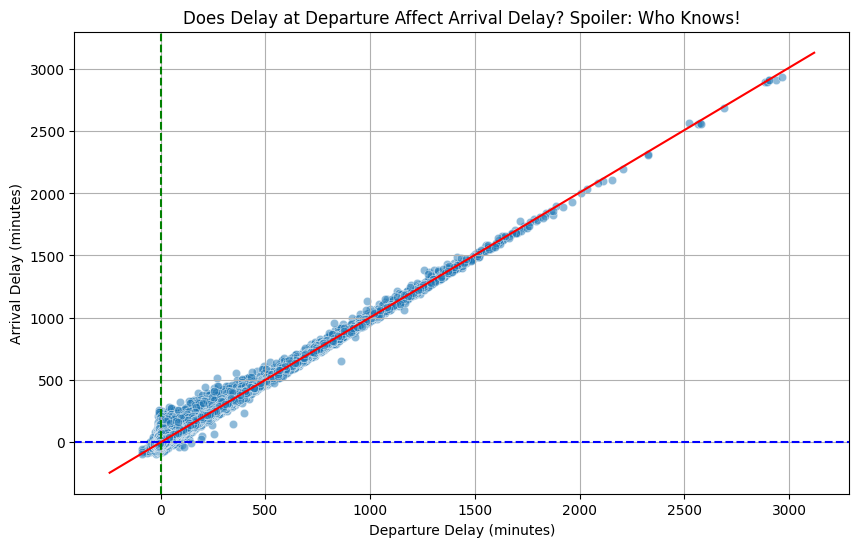

In [13]:
# plotting linear regression of our first question
plt.figure(figsize=(10, 6))
sns.scatterplot(x="DEP_DELAY", y="ARR_DELAY", data=fdf, alpha=0.5)

plt.title("Does Delay at Departure Affect Arrival Delay? Spoiler: Who Knows!")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for on-time arrivals
plt.axvline(0, color="green", linestyle="--")  # Reference line for on-time departures

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = np_b + np_m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.show()

In [14]:
# let's try a scond order polynomial and calculate R² along the way
coefs = np.polyfit(fdf["haversine_distance"], fdf["total_drift_distance"], 2)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf["haversine_distance"])

ss_res = np.sum((fdf["total_drift_distance"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf["total_drift_distance"] - np.mean(fdf["total_drift_distance"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)
                
print("Coefficients for polynomial: ", coefs)
print("R² of the polynomial: ", poly_r_squared)

Coefficients for polynomial:  [ 1.63557217e-04 -3.32986836e-02 -6.75381345e+00]
R² of the polynomial:  0.9350622945772229


In [15]:
# setup polynomial for plot
poly_x_vals = np.linspace(fdf["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
poly_y_vals = np.polyval(coefs, poly_x_vals)

/home/jnja/.venv_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


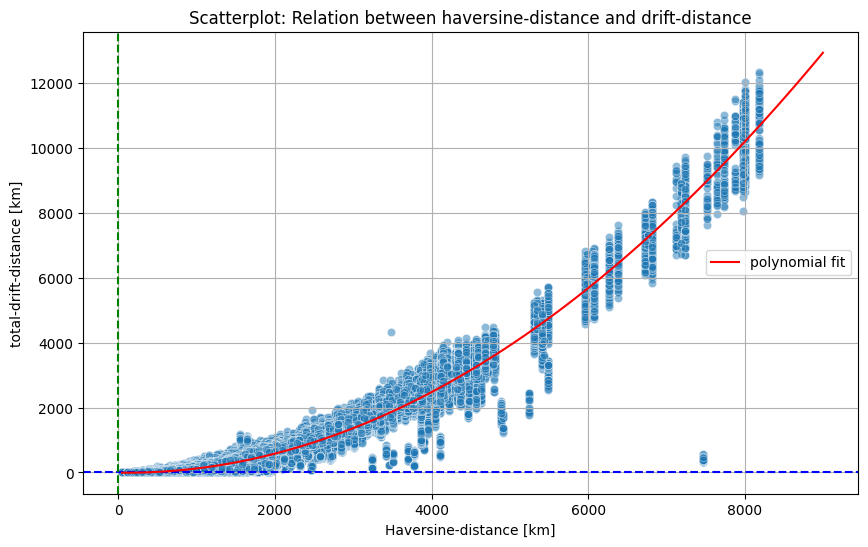

In [16]:
# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-distance")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# plotting polynomial
plt.plot(poly_x_vals, poly_y_vals, color="red", label="polynomial fit")

plt.grid(True)
plt.legend()
plt.show()

In [17]:
# linear regression using scikit-learn
X = fdf["haversine_distance"].values.reshape(-1, 1)
Y = fdf["total_drift_distance"].values

model = LinearRegression()
model.fit(X, Y)

scikit_m = model.coef_[0]
scikit_b = model.intercept_
r_squared = model.score(X, Y)

In [18]:
print("Slope by scikit-learn (m): ", scikit_m)
print("Intercept by scikit-learn (b): ", scikit_b)
print("R² by scikit-learn: ", r_squared)

Slope by scikit-learn (m):  0.6286179014537248
Intercept by scikit-learn (b):  -444.5952012899554
R² by scikit-learn:  0.804684452009402


/home/jnja/.venv_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


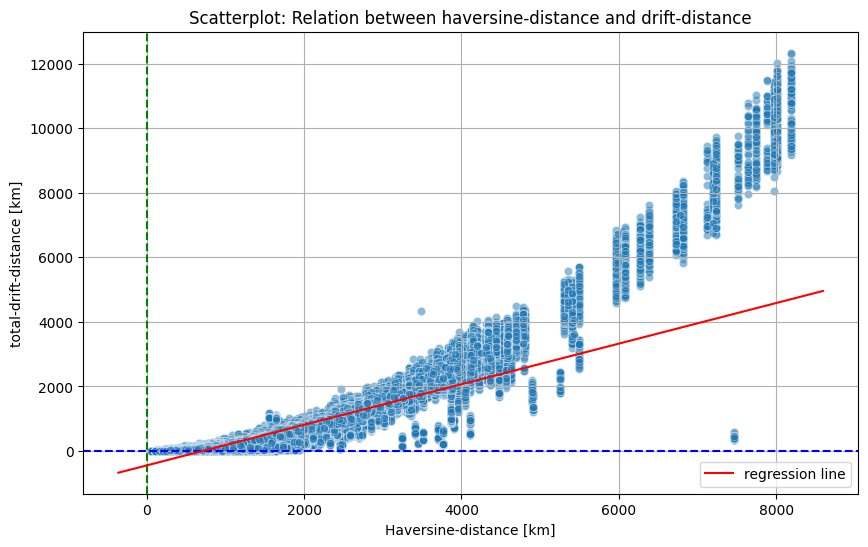

In [19]:
# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-distance")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.legend()
plt.show()

/home/jnja/.venv_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


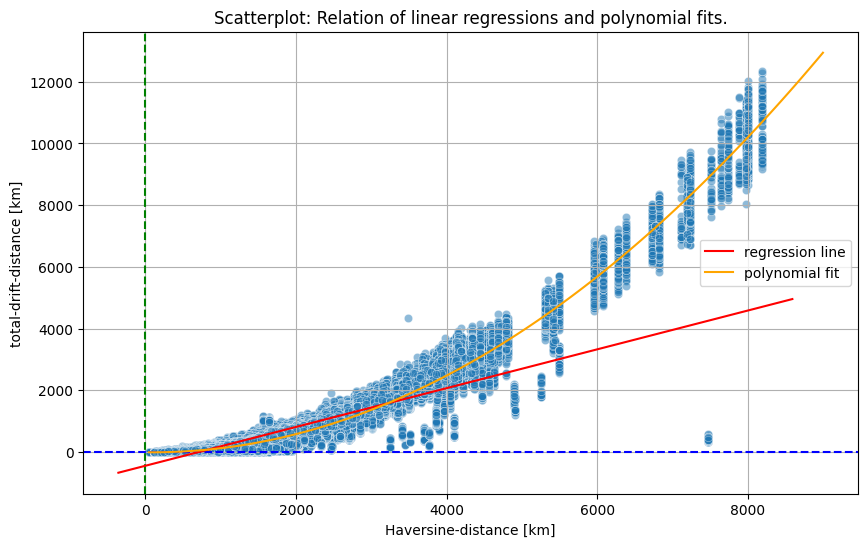

In [20]:
# let's compare and figure out the questions later!
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation of linear regressions and polynomial fits.")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

# adding polynomial for plot
plt.plot(poly_x_vals, poly_y_vals, color="orange", label="polynomial fit")

plt.grid(True)
plt.legend()
plt.show()

In [21]:
# other linear regression using scikit-learn
X = fdf["haversine_distance"].values.reshape(-1, 1)
Y = fdf["drift_factor"].values

model = LinearRegression()
model.fit(X, Y)

scikit_m = model.coef_[0]
scikit_b = model.intercept_
r_squared = model.score(X, Y)

In [22]:
print("Slope by scikit-learn (m): ", scikit_m)
print("Intercept by scikit-learn (b): ", scikit_b)
print("R² by scikit-learn: ", r_squared)

Slope by scikit-learn (m):  0.00015439496976308952
Intercept by scikit-learn (b):  -0.020122309114499998
R² by scikit-learn:  0.7917381789779261


/home/jnja/.venv_ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


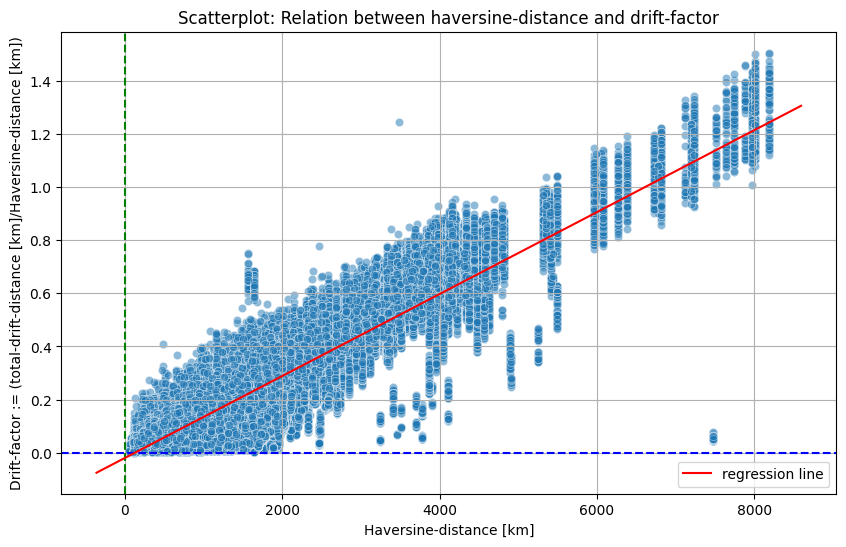

In [23]:
# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-factor")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("Drift-factor := (total-drift-distance [km]/Haversine-distance [km])")

plt.axhline(0, color="blue", linestyle="--")  # Reference line x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.legend()
plt.show()